# Visualizing results

In [1]:
import os
import pandas as pd
import plotnine as pln

In [2]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

In [3]:
prot_lengths = {}

# viral proteins
for prot in os.listdir('../data/viral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/viral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# non-viral proteins
for prot in os.listdir('../data/cellular/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/cellular/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# Viral x Non-viral proteins

In [6]:
cols = ['Fold', 'R2_score_train', 'MAE_score_train', 'RMSE_score_train',
       'R2_score_test', 'MAE_score_test', 'RMSE_score_test', 'rho_score_train',
       'rho_score_test', 'dataset', 'Model', 'Source']

In [7]:
res_esm2 = pd.DataFrame()
for source in ['viral', 'cellular']:
    for method in ['pool_split', 'site_split']:
        res_dir_path = f'../experiments/lassoCV/esm2_650m/{source}/{method}/'
        res = read_results(res_dir_path, 'esm2')
        res['Source'] = source
        res['Split'] = method
        
        if method == 'pool_split':
            res['Split'] = 'pooled'
        elif method == 'site_split':
            res['Split'] = 'site'
        res_esm2 = pd.concat([res_esm2, res], ignore_index=True)


res_esm2['prot_length'] = res_esm2['Dataset'].map(prot_lengths)
cols=['rho_score_test', 'R2_score_test', 'rho_score_train', 'R2_score_train', 'prot_length']
res_esm2 = res_esm2.groupby(['Model', 'Dataset', 'Split', 'Source'], as_index=False)[cols].mean()
res_esm2['Source'] = pd.Categorical(res_esm2['Source'], categories=['viral', 'cellular'])
res_esm2

,Model,Dataset,Split,Source,rho_score_test,R2_score_test,rho_score_train,R2_score_train,prot_length
0,esm2,AMIE_PSEAE_Whitehead,pooled,cellular,0.740800,0.477524,0.791640,0.589139,346.0
1,esm2,AMIE_PSEAE_Whitehead,site,cellular,0.491775,0.222458,0.665746,0.398576,346.0
2,esm2,B3VI55_LIPSTSTABLE,pooled,cellular,0.698285,0.451530,0.765475,0.557978,439.0
3,esm2,B3VI55_LIPSTSTABLE,site,cellular,0.579191,0.268583,0.660729,0.394301,439.0
4,esm2,B3VI55_LIPST_Whitehead2015,pooled,cellular,0.470285,0.245162,0.557411,0.353876,439.0
...,...,...,...,...,...,...,...,...,...
143,esm2,UBC9_HUMAN_Roth2017,site,cellular,0.477692,0.140908,0.785352,0.564137,159.0
144,esm2,UBE4B_MOUSE_Klevit2013_singles,pooled,cellular,0.539405,0.265605,0.709845,0.531110,1173.0
145,esm2,UBE4B_MOUSE_Klevit2013_singles,site,cellular,0.322258,0.087491,0.471425,0.199477,1173.0
146,esm2,YAP1_HUMAN_Fields2012_singles,pooled,cellular,0.666008,0.459191,0.897942,0.791618,504.0


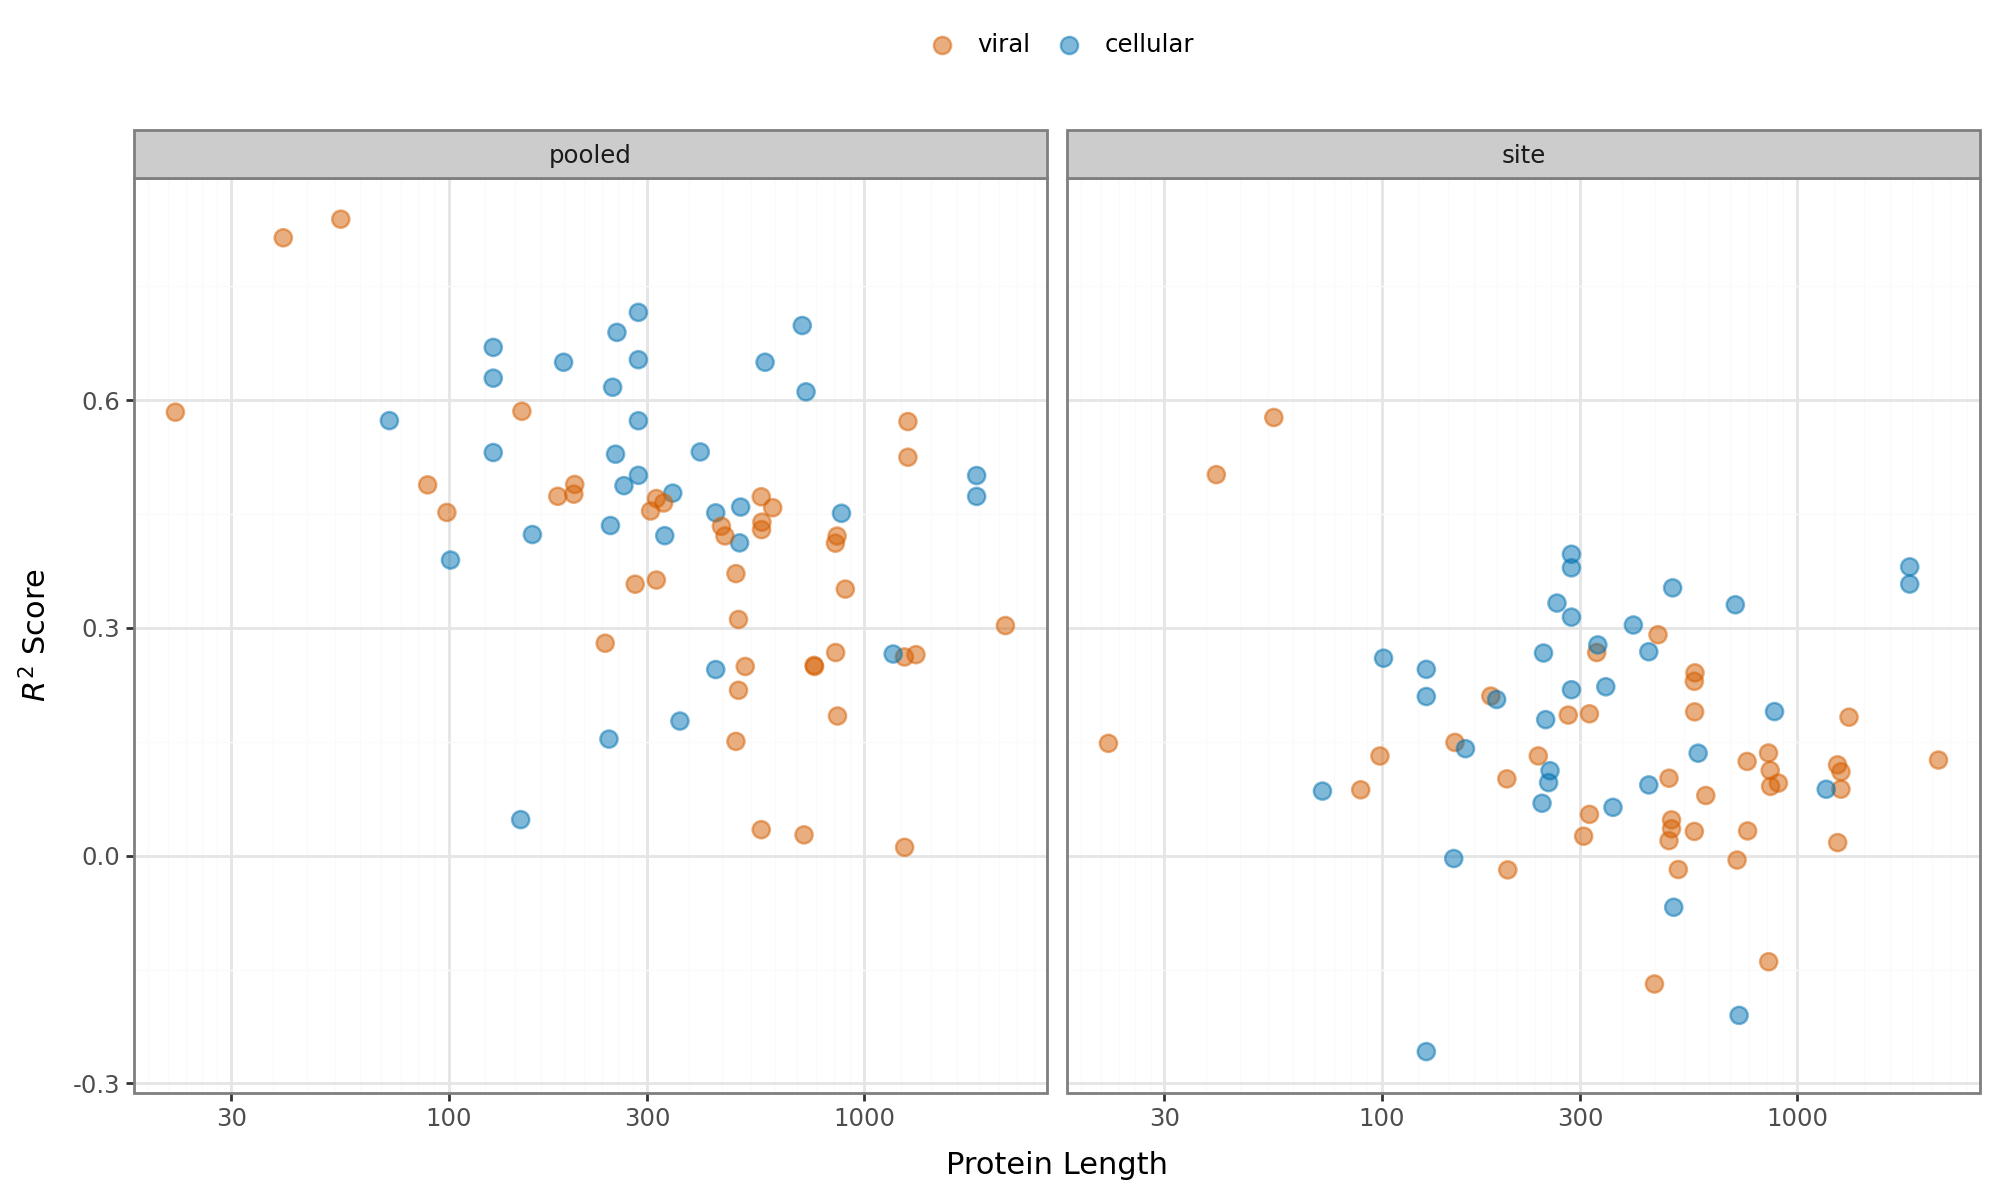

In [8]:
plot = (
    pln.ggplot(res_esm2, pln.aes(x='prot_length', y='R2_score_test'))
    + pln.geom_point(pln.aes(color='Source'), size=3, alpha=0.5)
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_wrap('Split')
    + pln.scale_x_log10()
    + pln.labs(x="Protein Length", y="$R^2$ Score")
    + pln.theme_bw()
    + pln.theme(figure_size=(10, 6), legend_position='top',legend_title=pln.element_blank())
    #+ pln.ylim(-0.2, 0.8)

)
plot#.save(filename='../experiments/protein_length_vs_lassocv_r2_full.png', dpi=600)

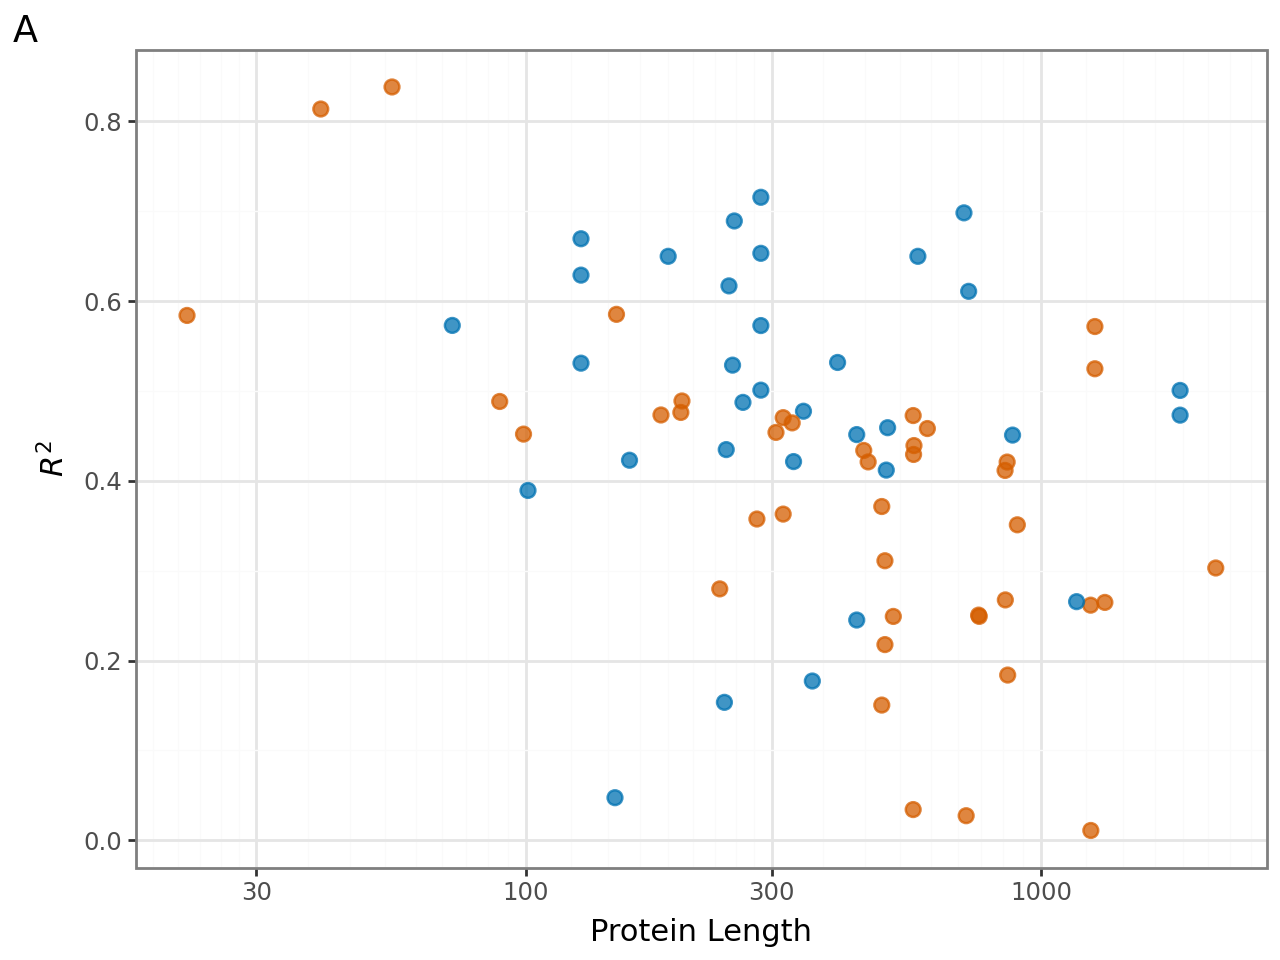

In [9]:
res_pooled = res_esm2.query('Split == "pooled"')
p1 = (
    pln.ggplot(res_pooled, pln.aes(x='prot_length', y='R2_score_test'))
    + pln.geom_point(pln.aes(color='Source'), size=2.5, alpha=0.75)
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.scale_x_log10()
    + pln.labs(
        x="Protein Length", 
        y="$R^2$",
        tag="A")
    + pln.theme_bw()
    + pln.theme(
        #figure_size=(4.5, 3.5), 
        legend_position='none', legend_title=pln.element_blank())
)
p1

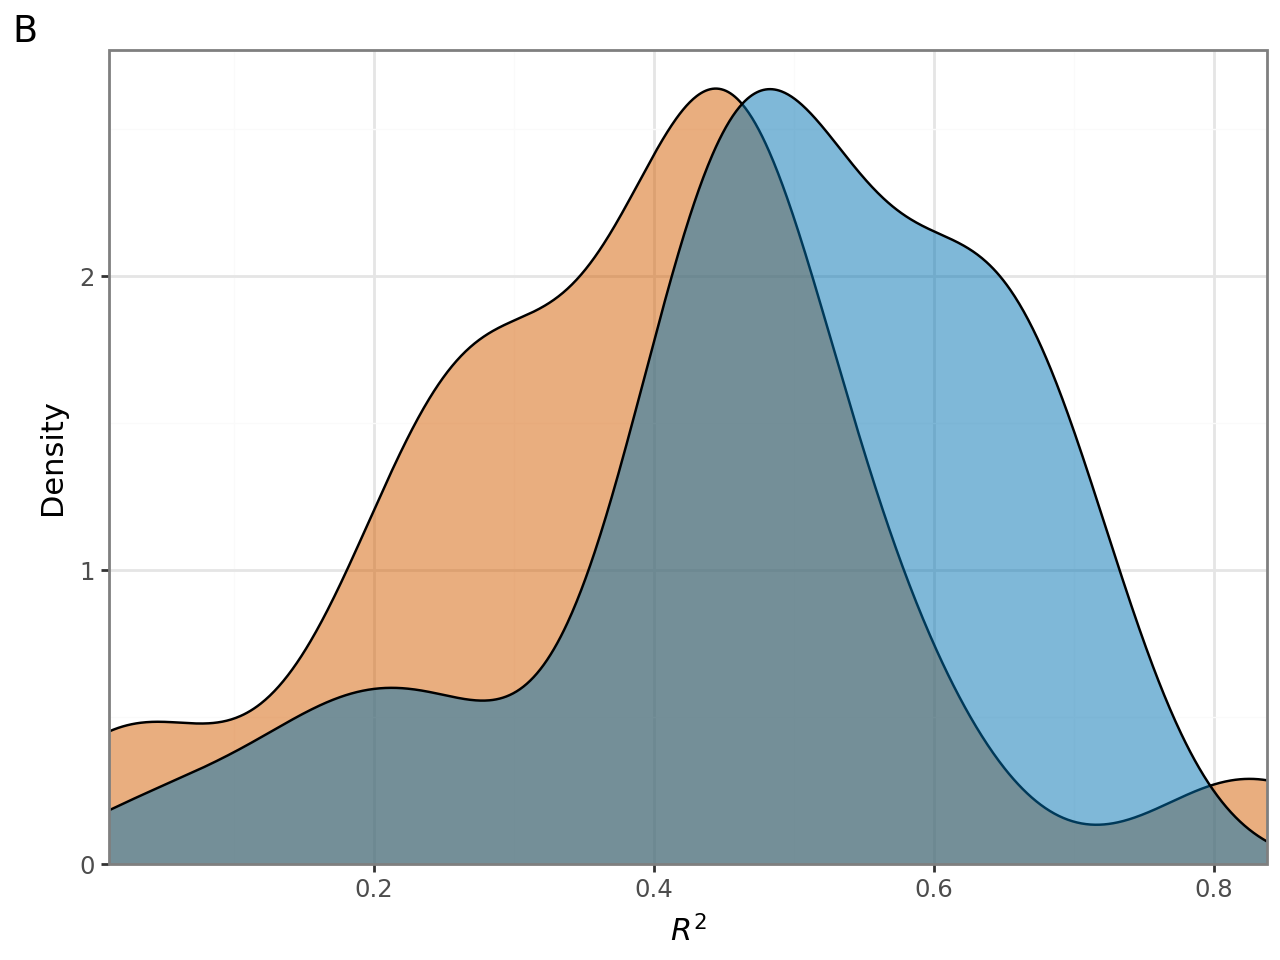

In [10]:
p2 = (
    pln.ggplot(res_pooled, pln.aes(x='R2_score_test'))
    + pln.geom_density(pln.aes(fill='Source'),  alpha=0.5)
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.labs(
        x="$R^2$", 
        y="Density",
        tag="B")
    + pln.theme_bw()
    + pln.theme(
        #figure_size=(4.5, 3.5), 
        legend_position='none',
        legend_title=pln.element_blank())

)
p2

# Fine tuned models

In [30]:
res_full = pd.DataFrame() 
for model in ['esm2_650m', 'esmc_600m', 'rsawhney_esm2_3B', 'esm2_viral_650m_MP15_partial_CRVDBv30', 'esm2_viral_650m_MP15_partial_URVDBv30']:
    for source in ['viral', 'cellular']:
        for method in ['pool_split', 'site_split']:
            res_dir_path = f'../experiments/lassoCV/{model}/{source}/{method}/'
            res = read_results(res_dir_path, model)
            res['Source'] = source
            res['Split'] = method
            res_full = pd.concat([res_full, res], ignore_index=True)

rename_map = {
    'esm2_650m':'ESM-2 650M',
    'esmc_600m':'ESM C 600M',
    'esm2_viral_650m_MP15_partial_CRVDBv30':'ESM-2-CRVDB', 
    'esm2_viral_650m_MP15_partial_URVDBv30':'ESM-2-URVDB', 
    'rsawhney_esm2_3B':'ESM-2 3B Sawhney',
    'pool_split':'Random Split',
    'site_split':'Site Split',
    }

res_full.replace(rename_map, inplace=True)
res_full['prot_length'] = res_full['Dataset'].map(prot_lengths)
res_full

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_nonzero_coefs,Dataset,Source,Split,prot_length
0,ESM-2 650M,1,0.595066,0.465875,0.642610,0.499775,0.496724,0.678049,0.623398,0.544245,267,SARS2_PRD0038_RBD_Starr,viral,Random Split,200
1,ESM-2 650M,2,0.603862,0.452948,0.627526,0.520908,0.502435,0.700182,0.624444,0.596304,276,SARS2_PRD0038_RBD_Starr,viral,Random Split,200
2,ESM-2 650M,3,0.589508,0.472382,0.652183,0.407867,0.495722,0.709779,0.622881,0.528574,246,SARS2_PRD0038_RBD_Starr,viral,Random Split,200
3,ESM-2 650M,1,0.452034,0.520602,0.729537,0.231151,0.688557,0.925848,0.627984,0.397335,44,HIV1_HV1B9_ENV_DuenasDecamp,viral,Random Split,853
4,ESM-2 650M,2,0.503739,0.510456,0.698138,0.244454,0.645255,0.898591,0.658186,0.418242,53,HIV1_HV1B9_ENV_DuenasDecamp,viral,Random Split,853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2209,ESM-2-URVDB,2,0.284383,0.717758,0.851805,0.124960,0.749984,0.905935,0.575242,0.367645,43,BLAT_ECOLX_Palzkill2012,cellular,Site Split,286
2210,ESM-2-URVDB,3,0.220219,0.749066,0.885473,0.133366,0.768693,0.918483,0.506713,0.405565,29,BLAT_ECOLX_Palzkill2012,cellular,Site Split,286
2211,ESM-2-URVDB,1,0.497174,0.594228,0.707522,0.296677,0.721051,0.845913,0.737196,0.560521,87,BLAT_ECOLX_Ranganathan2015,cellular,Site Split,286
2212,ESM-2-URVDB,2,0.621786,0.503264,0.611576,0.355462,0.640081,0.811300,0.805704,0.644728,175,BLAT_ECOLX_Ranganathan2015,cellular,Site Split,286


In [31]:
cols=['rho_score_test', 'R2_score_test', 'rho_score_train', 'R2_score_train']
res_full = res_full.groupby(['Model', 'Source', 'Dataset', 'Split'], as_index=False)[cols].mean()
res_full['Model'] = pd.Categorical(res_full['Model'], categories=['ESM-2 650M', 'ESM C 600M', 'ESM-2-CRVDB', 'ESM-2-URVDB', 'ESM-2 3B Sawhney'])
res_full ['Source'] = pd.Categorical(res_full['Source'], categories=['viral', 'cellular'])
res_full 

,Model,Source,Dataset,Split,rho_score_test,R2_score_test,rho_score_train,R2_score_train
0,ESM C 600M,cellular,AMIE_PSEAE_Whitehead,Random Split,0.724979,0.474063,0.764256,0.546157
1,ESM C 600M,cellular,AMIE_PSEAE_Whitehead,Site Split,0.495757,0.260337,0.640062,0.386109
2,ESM C 600M,cellular,B3VI55_LIPSTSTABLE,Random Split,0.655235,0.409322,0.705427,0.475469
3,ESM C 600M,cellular,B3VI55_LIPSTSTABLE,Site Split,0.567025,0.286138,0.574451,0.303758
4,ESM C 600M,cellular,B3VI55_LIPST_Whitehead2015,Random Split,0.455423,0.223819,0.529957,0.305142
...,...,...,...,...,...,...,...,...
733,ESM-2-URVDB,viral,SARS2_RBD_binding_Starr,Site Split,0.223105,0.100535,0.422320,0.262972
734,ESM-2-URVDB,viral,SARS2_RBD_expression_Starr,Random Split,0.770078,0.612718,0.854438,0.755839
735,ESM-2-URVDB,viral,SARS2_RBD_expression_Starr,Site Split,0.297997,0.091858,0.462705,0.190213
736,ESM-2-URVDB,viral,SARS2_XBB15_RBD_Taylor,Random Split,0.681399,0.593932,0.727697,0.748399


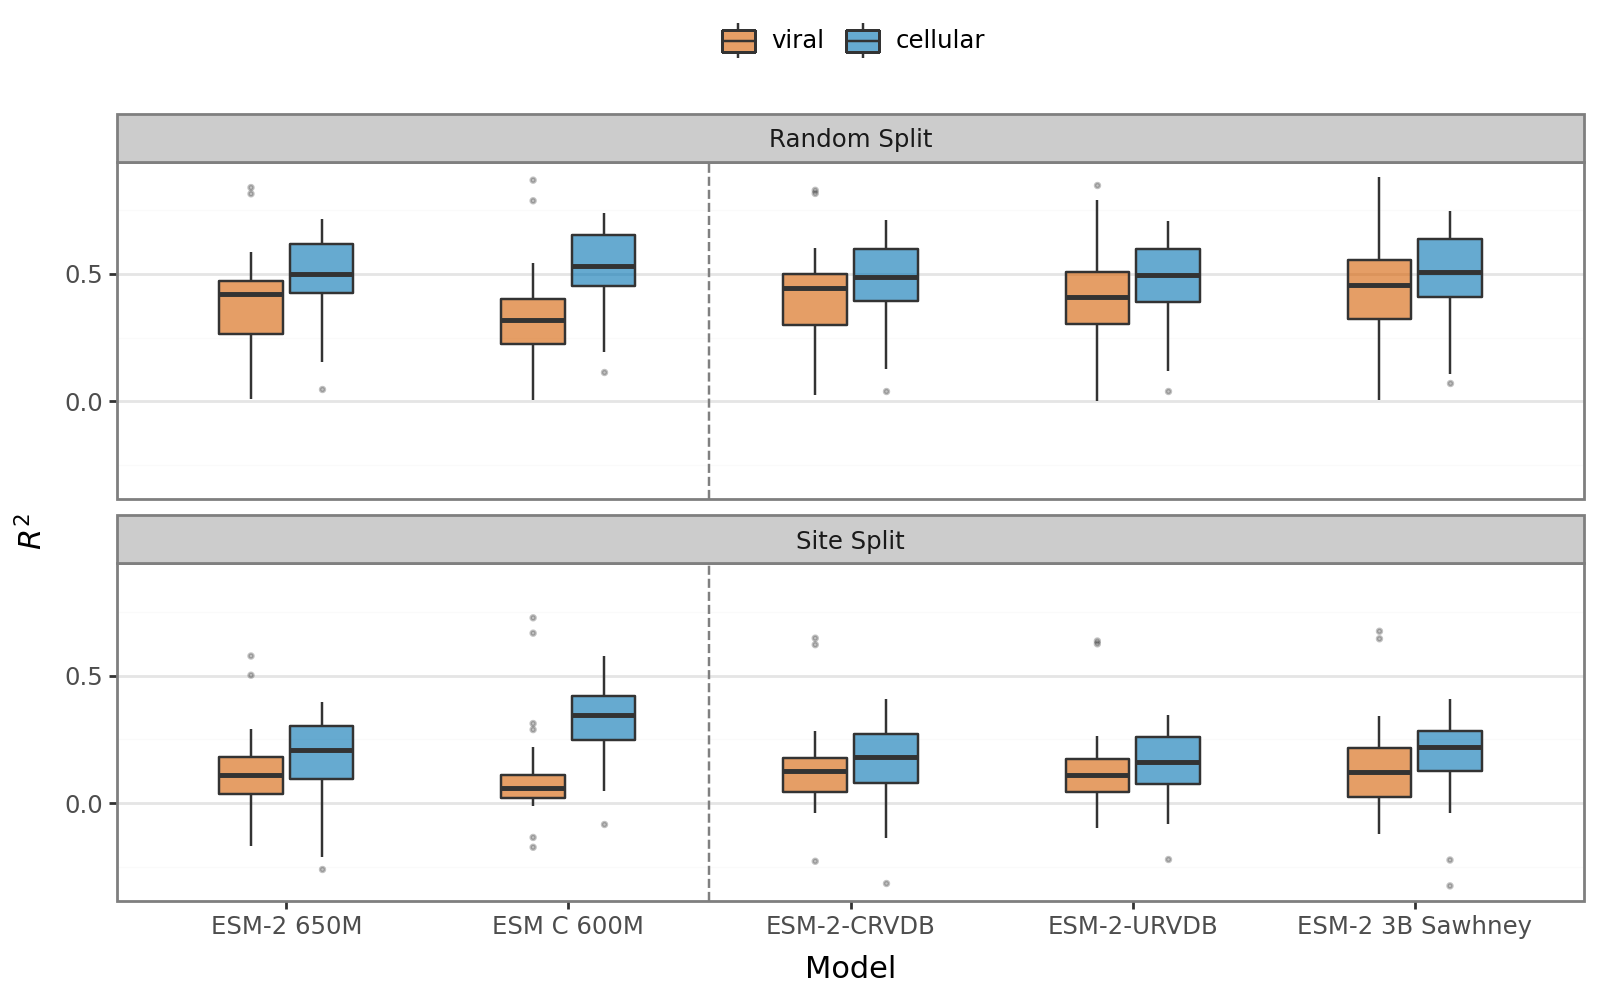

In [32]:
plot = (
    pln.ggplot(res_full, pln.aes(x='Model', y='R2_score_test', fill='Source'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5, alpha=0.6)
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_vline(xintercept=2.5, linetype='dashed', color='gray', size=0.5)
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.facet_wrap('~Split', nrow=2)
    + pln.theme(
        figure_size=(8, 5),
        panel_grid_major_x=pln.element_blank(),
        legend_position='top',
        legend_title=pln.element_blank()
    )
)

plot#.save(filename='../experiments/lassoCV_finetuned_models.png', dpi=600)

In [33]:
res_full_pooled = res_full.query('Split == "Random Split"')
res_full_pooled

,Model,Source,Dataset,Split,rho_score_test,R2_score_test,rho_score_train,R2_score_train
0,ESM C 600M,cellular,AMIE_PSEAE_Whitehead,Random Split,0.724979,0.474063,0.764256,0.546157
2,ESM C 600M,cellular,B3VI55_LIPSTSTABLE,Random Split,0.655235,0.409322,0.705427,0.475469
4,ESM C 600M,cellular,B3VI55_LIPST_Whitehead2015,Random Split,0.455423,0.223819,0.529957,0.305142
6,ESM C 600M,cellular,BG_STRSQ_hmmerbit,Random Split,0.718349,0.527707,0.761456,0.588156
8,ESM C 600M,cellular,BLAT_ECOLX_Ostermeier2014,Random Split,0.837716,0.653661,0.864997,0.701656
...,...,...,...,...,...,...,...,...
728,ESM-2-URVDB,viral,SARS2_PLPRO_activity_Wu,Random Split,0.720258,0.545268,0.797653,0.690479
730,ESM-2-URVDB,viral,SARS2_PRD0038_RBD_Starr,Random Split,0.556844,0.506069,0.623164,0.626870
732,ESM-2-URVDB,viral,SARS2_RBD_binding_Starr,Random Split,0.673099,0.615926,0.766438,0.769914
734,ESM-2-URVDB,viral,SARS2_RBD_expression_Starr,Random Split,0.770078,0.612718,0.854438,0.755839


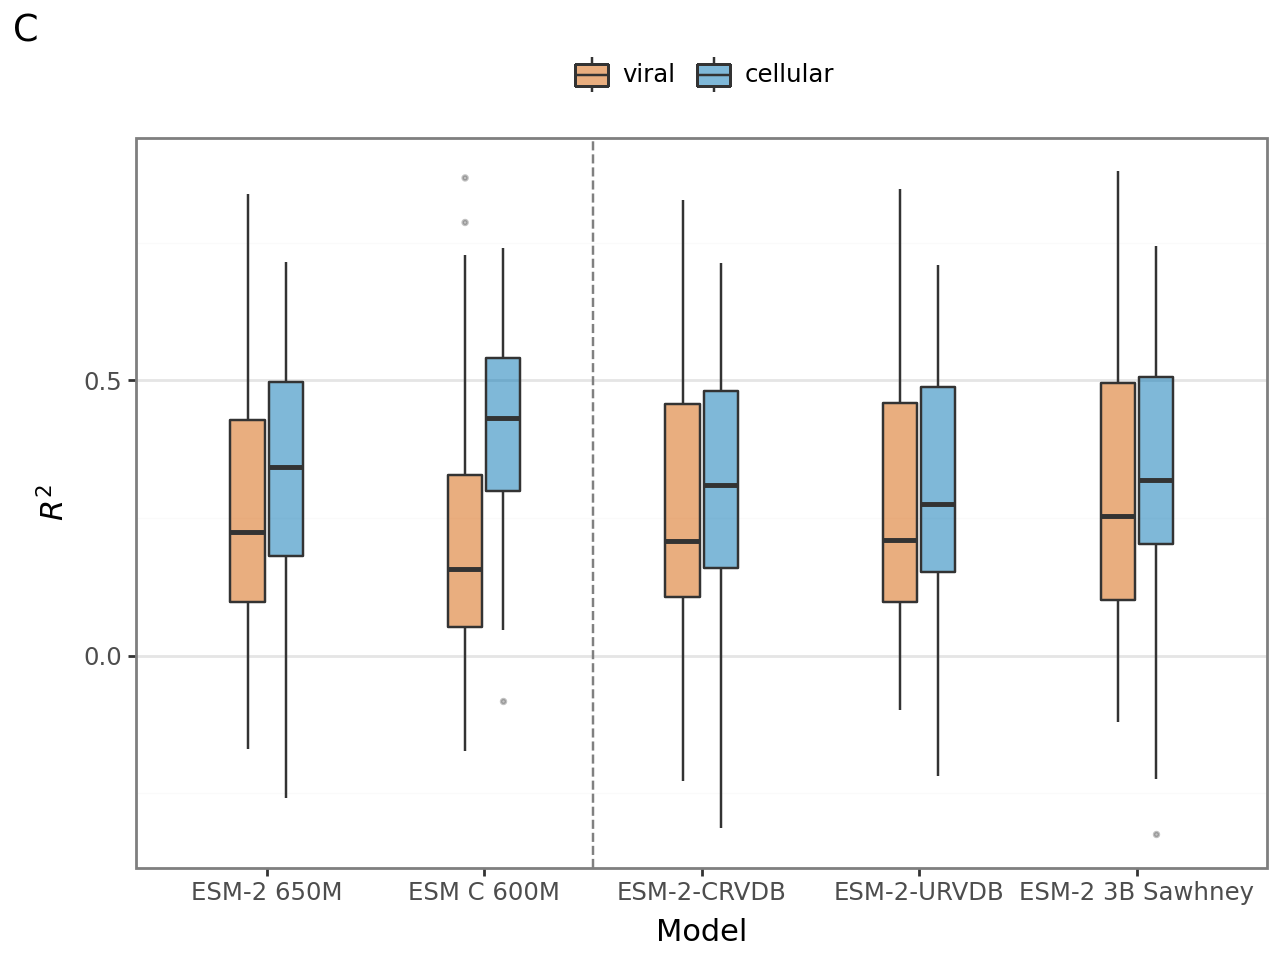

In [16]:
p3 = (
    pln.ggplot(res_full, pln.aes(x='Model', y='R2_score_test',fill='Source'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.35, alpha=0.5)
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_vline(xintercept=2.5, linetype='dashed', color='gray', size=0.5)
    + pln.labs(
        x='Model',
        y='$R^2$',
        tag='C'
    )
    + pln.theme_bw()
    + pln.theme(
        legend_position='top',
        panel_grid_major_x=pln.element_blank(),
        legend_title=pln.element_blank(),
        legend_key=pln.element_rect(fill='white', color='black')
        )
)

p3

In [58]:
#res_full.groupby(['Model', 'Split', 'Source'], as_index=False)[cols].mean()

# Composed figure

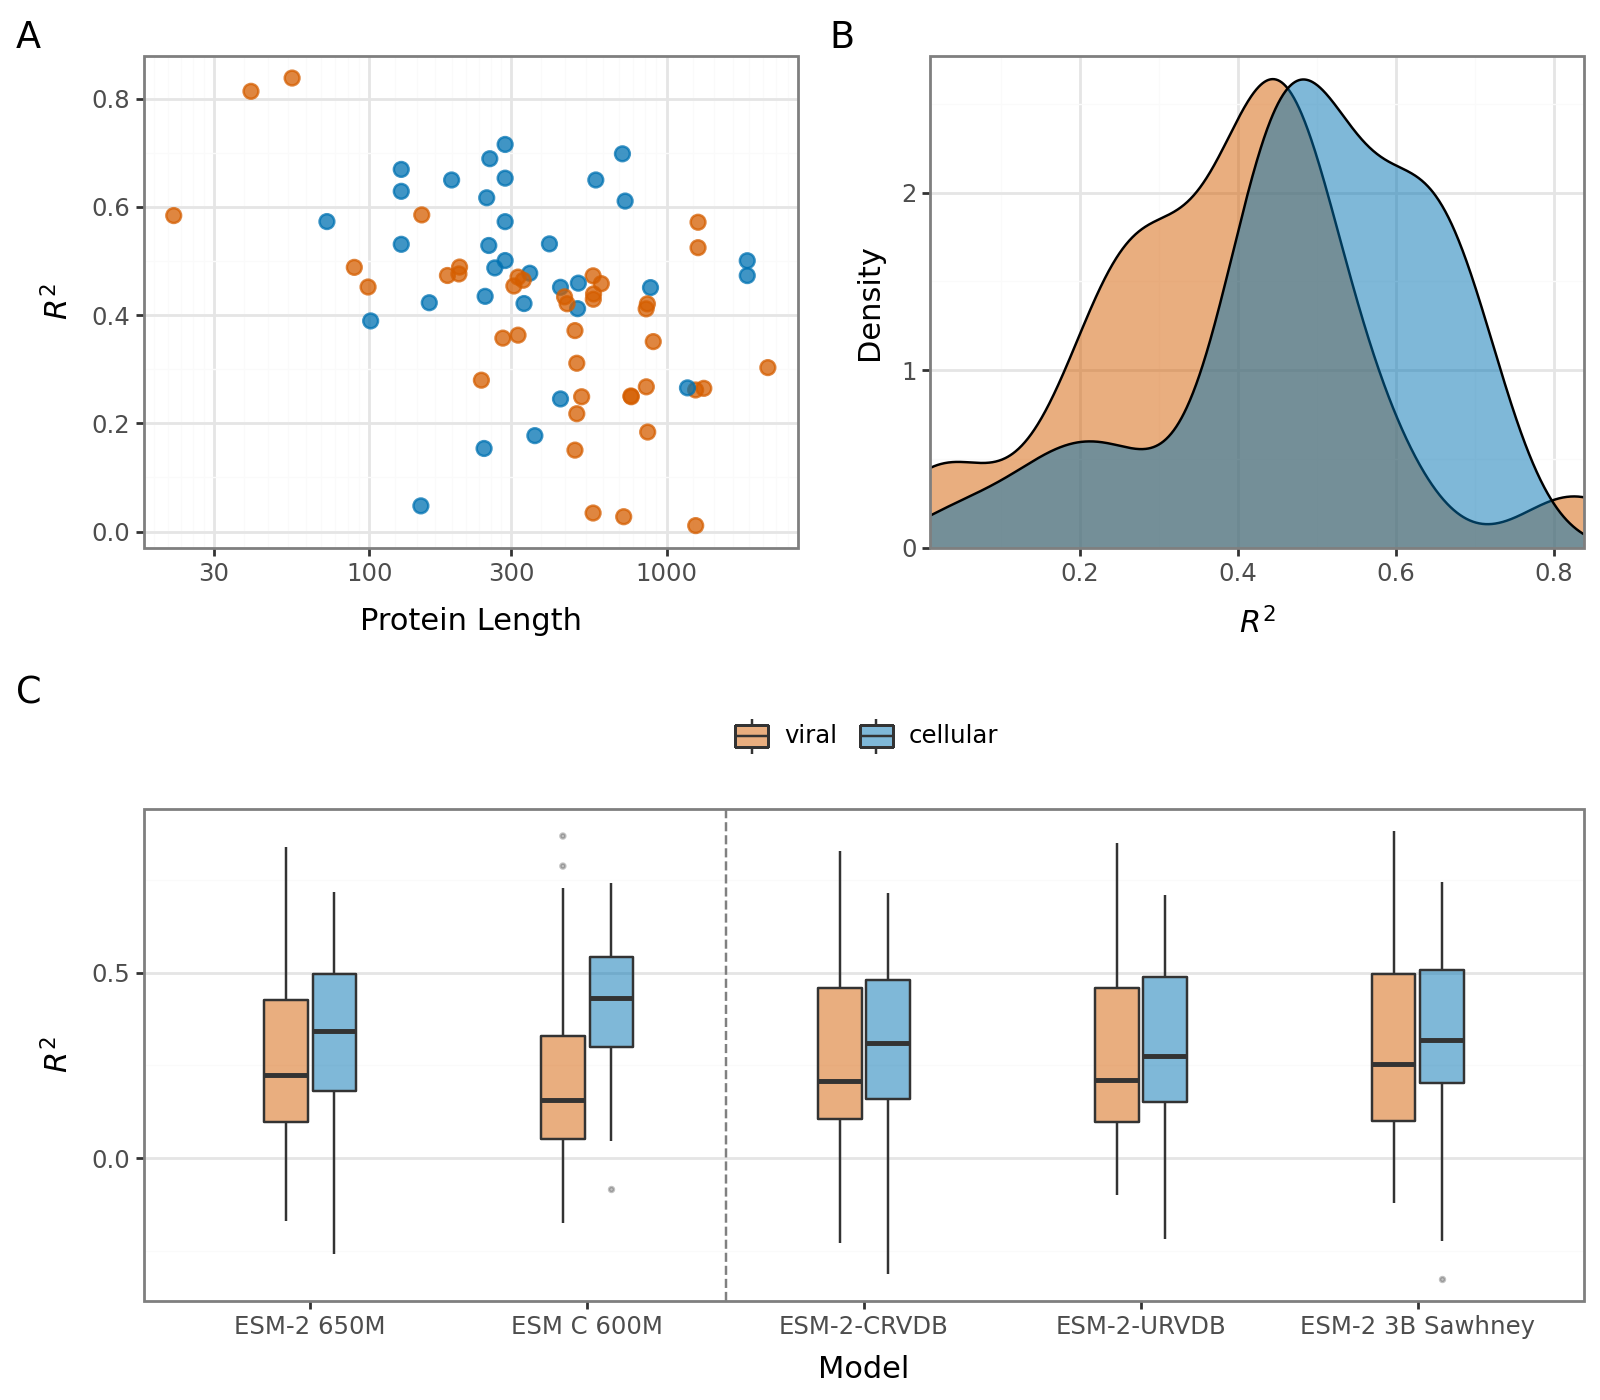

In [19]:

comp = (p1 | p2) / p3
plot = comp + pln.theme(figure_size=(8, 7.))
plot#.save(filename='../experiments/comp1_lassoCV.png', dpi=600)

# Lasso results all models

In [1]:
# avg = pd.read_csv('../experiments/AVG/results_AVG_3folds_all.csv', index_col=0)
# rename_map = {
#     'pooled':'Random Split',
#     'site':'Site Split',
#     }
# avg.replace(rename_map, inplace=True)
# avg = avg.groupby(['Model', 'Source', 'Split', 'Dataset'], as_index=False)['R2_score_test'].mean()
# avg

In [6]:
lassocv = pd.DataFrame()
for model in ['esm2_650m', 'esmc_600m', 'rsawhney_esm2_3B', 'esm2_viral_650m_MP15_partial_CRVDBv30', 'esm2_viral_650m_MP15_partial_URVDBv30']:
    for source in ['viral', 'cellular']:
        for method in ['pool_split', 'site_split']:
            res_dir_path = f'../experiments/lassoCV/{model}/{source}/{method}/'
            res = read_results(res_dir_path, model)
            res['Source'] = source
            res['Split'] = method
            
            lassocv = pd.concat([lassocv, res], ignore_index=True)

rename_map = {
    'esm2_650m':'ESM-2 650M',
    'esmc_600m':'ESM C 600M',
    'esm2_viral_650m_MP15_partial_CRVDBv30':'ESM-2-CRVDB', 
    'esm2_viral_650m_MP15_partial_URVDBv30':'ESM-2-URVDB', 
    'rsawhney_esm2_3B':'ESM-2 3B Sawhney',
    'pool_split':'Pooled Split',
    'site_split':'Site Split',
    }

lassocv.replace(rename_map, inplace=True)
lassocv = lassocv.groupby(['Model', 'Source', 'Split', 'Dataset'], as_index=False)['R2_score_test'].mean()
lassocv

,Model,Source,Split,Dataset,R2_score_test
0,ESM C 600M,cellular,Pooled Split,AMIE_PSEAE_Whitehead,0.474063
1,ESM C 600M,cellular,Pooled Split,B3VI55_LIPSTSTABLE,0.409322
2,ESM C 600M,cellular,Pooled Split,B3VI55_LIPST_Whitehead2015,0.223819
3,ESM C 600M,cellular,Pooled Split,BG_STRSQ_hmmerbit,0.527707
4,ESM C 600M,cellular,Pooled Split,BLAT_ECOLX_Ostermeier2014,0.653661
...,...,...,...,...,...
733,ESM-2-URVDB,viral,Site Split,SARS2_PLPRO_activity_Wu,0.199473
734,ESM-2-URVDB,viral,Site Split,SARS2_PRD0038_RBD_Starr,0.111117
735,ESM-2-URVDB,viral,Site Split,SARS2_RBD_binding_Starr,0.100535
736,ESM-2-URVDB,viral,Site Split,SARS2_RBD_expression_Starr,0.091858


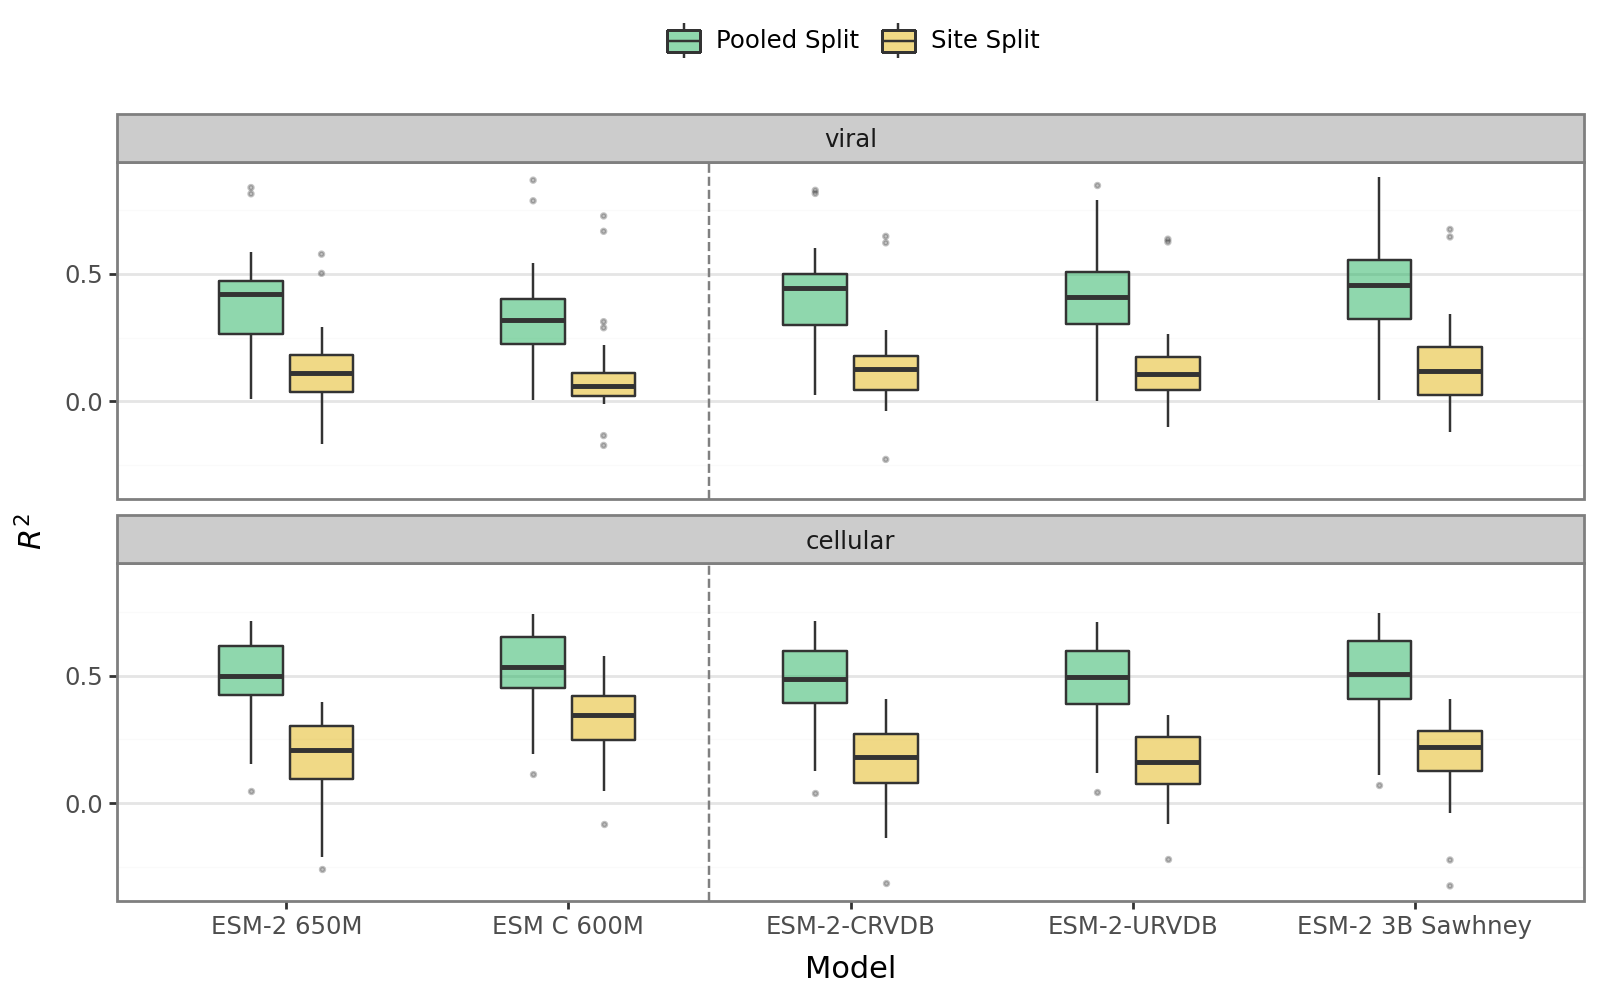

In [10]:
full_res = lassocv
full_res['Model'] = pd.Categorical(full_res['Model'], categories=['ESM-2 650M', 'ESM C 600M', 'ESM-2-CRVDB', 'ESM-2-URVDB', 'ESM-2 3B Sawhney'])
full_res['Source'] = pd.Categorical(full_res['Source'], categories=['viral', 'cellular'])

plot = (
    pln.ggplot(full_res, pln.aes(fill='Split', y='R2_score_test', x='Model'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5, alpha=0.5 )
    + pln.geom_vline(xintercept=2.5, linetype='dashed', color='gray', size=0.5)
    + pln.scale_fill_manual(values={"Pooled Split": "#20B15C", "Site Split": "#E2B40E"})
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.facet_wrap('~Source', nrow=2)
    + pln.theme(
        figure_size=(8, 5),
        panel_grid_major_x=pln.element_blank(),
        legend_position='top',
        legend_title=pln.element_blank()
    )
)

plot#.save(filename='../experiments/fig4_site_x_random_all_models.png', dpi=600)